# Customer Churn Prediction — Telco Dataset

End-to-end churn prediction project: exploratory data analysis, feature engineering,
model comparison, and evaluation.

**Dataset:** IBM Telco Customer Churn (7,043 customers, 21 raw features)
**Target:** `Churn` (Yes/No)


In [1]:
import sys
sys.path.append("../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from preprocessing import load_raw, clean, add_features, split_data, TARGET

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)


## 1. Load and inspect raw data

In [2]:
raw = load_raw("../data/Telco-Customer-Churn.csv")
print(raw.shape)
raw.head()


(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
raw.isna().sum().sort_values(ascending=False).head(10)


customerID         0
gender             0
SeniorCitizen      0
Partner            0
Dependents         0
tenure             0
PhoneService       0
MultipleLines      0
InternetService    0
OnlineSecurity     0
dtype: int64

`TotalCharges` is stored as a string and has a few blank values for customers
with zero tenure (brand-new customers). We'll coerce it to numeric and fill blanks with 0
during cleaning.

## 2. Clean and engineer features

In [5]:
df = clean(raw)
df = add_features(df)
df.shape


(7043, 23)

In [6]:
df[TARGET].value_counts(normalize=True).rename("share")


Churn
0    0.73463
1    0.26537
Name: share, dtype: float64

Churn rate is about **26.5%**, so the classes are moderately imbalanced.
We'll account for this with `class_weight="balanced"` / `scale_pos_weight` during modeling
rather than naive resampling, to avoid distorting the feature distributions.

## 3. Exploratory Data Analysis

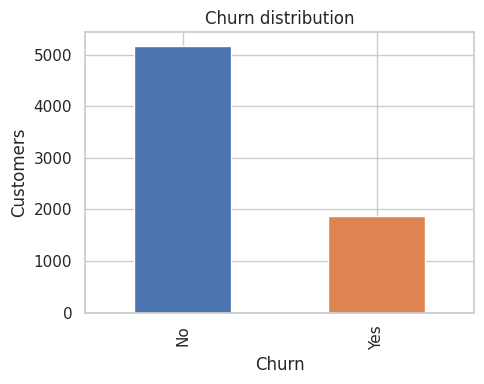

In [7]:
fig, ax = plt.subplots(figsize=(5, 4))
df[TARGET].map({0: "No", 1: "Yes"}).value_counts().plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_title("Churn distribution")
ax.set_xlabel("Churn")
ax.set_ylabel("Customers")
plt.tight_layout()
plt.show()


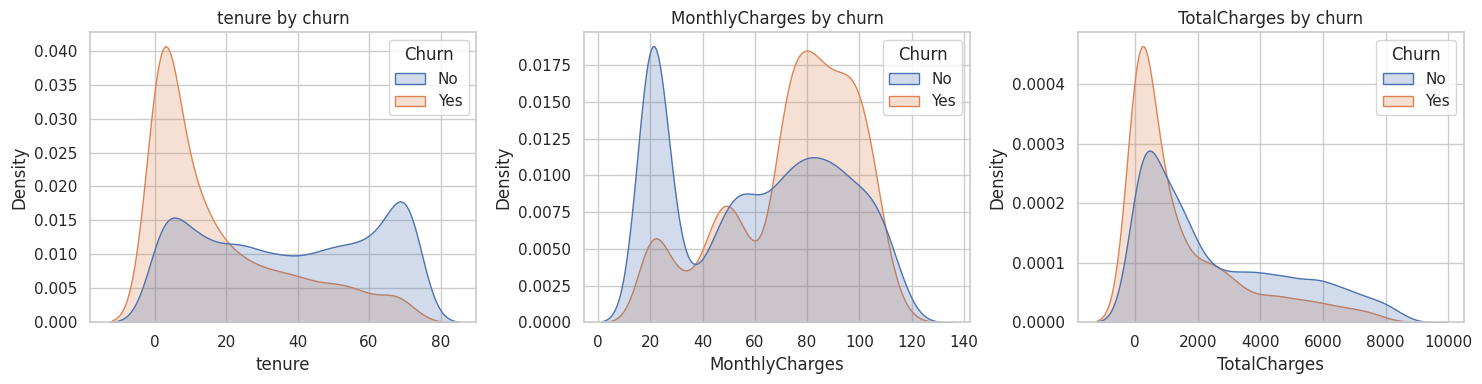

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["tenure", "MonthlyCharges", "TotalCharges"]):
    sns.kdeplot(data=df, x=col, hue=df[TARGET].map({0: "No", 1: "Yes"}), ax=ax, fill=True, common_norm=False)
    ax.set_title(f"{col} by churn")
plt.tight_layout()
plt.show()


Churners are disproportionately **new customers** (low tenure) paying **higher monthly charges**
relative to total lifetime spend — a classic early-life churn risk pattern.

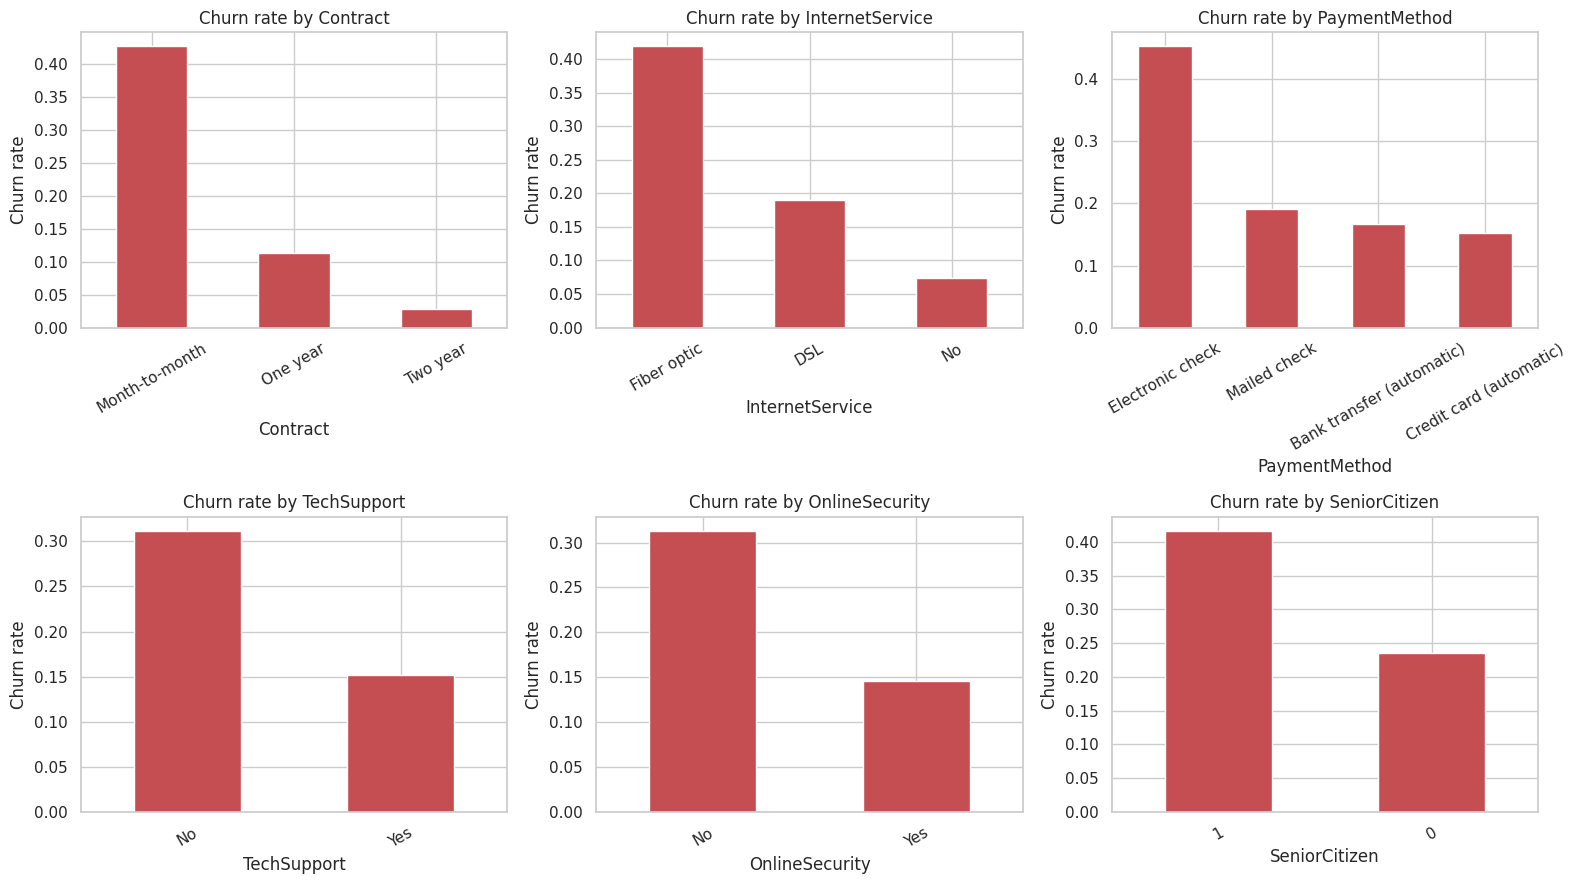

In [9]:
cat_cols = ["Contract", "InternetService", "PaymentMethod", "TechSupport", "OnlineSecurity", "SeniorCitizen"]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for ax, col in zip(axes, cat_cols):
    churn_rate = df.groupby(col)[TARGET].mean().sort_values(ascending=False)
    churn_rate.plot(kind="bar", ax=ax, color="#C44E52")
    ax.set_title(f"Churn rate by {col}")
    ax.set_ylabel("Churn rate")
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


Key risk factors emerging from the plots:
- **Month-to-month contracts** churn far more than one/two-year contracts.
- **Fiber optic internet** customers churn more than DSL or no-internet customers.
- **Electronic check** payers churn more than other payment methods.
- Customers without **TechSupport** or **OnlineSecurity** add-ons churn more.
- **Senior citizens** churn at a noticeably higher rate.


In [10]:
numeric_df = df.select_dtypes(include=["int64", "float64"])
corr = numeric_df.corr()[TARGET].sort_values(ascending=False)
corr


Churn              1.000000
MonthlyCharges     0.193356
AvgMonthlySpend    0.192531
SeniorCitizen      0.150889
NumServices       -0.067264
TotalCharges      -0.198324
tenure            -0.352229
Name: Churn, dtype: float64

## 4. Train / test split

In [11]:
X_train, X_test, y_train, y_test = split_data(df)
print(X_train.shape, X_test.shape)
print(y_train.mean(), y_test.mean())


(5634, 22) (1409, 22)
0.2653532126375577 0.2654364797728886


## 5. Build preprocessing + model pipelines

In [12]:
from train import build_preprocessor, get_candidate_models, evaluate
from sklearn.pipeline import Pipeline

preprocessor = build_preprocessor(X_train)
candidates = get_candidate_models()

results = {}
pipelines = {}

for name, model in candidates.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    metrics = evaluate(pipe, X_test, y_test)
    results[name] = metrics
    pipelines[name] = pipe

pd.DataFrame(results).T.sort_values("roc_auc", ascending=False)


,accuracy,precision,recall,f1,roc_auc
logistic_regression,0.738822,0.505051,0.802139,0.619835,0.845300
random_forest,0.769340,0.549696,0.724599,0.625144,0.842397
gradient_boosting,0.799858,0.659722,0.508021,0.574018,0.841882
xgboost,0.748758,0.517857,0.775401,0.620985,0.836972


**Logistic Regression** edges out the tree-based models on ROC AUC here, which is common
on tabular data of this size with mostly linear/monotonic relationships once categorical
variables are one-hot encoded. We'll select the model with the best ROC AUC as the final model,
since it balances ranking quality across the imbalanced classes.

## 6. Evaluate the best model in detail

In [13]:
best_name = max(results, key=lambda k: results[k]["roc_auc"])
best_pipeline = pipelines[best_name]
print("Best model:", best_name)

from sklearn.metrics import confusion_matrix, classification_report, RocCurveDisplay

y_pred = best_pipeline.predict(X_test)
print(classification_report(y_test, y_pred, target_names=["No churn", "Churn"]))


Best model: logistic_regression
              precision    recall  f1-score   support

    No churn       0.91      0.72      0.80      1035
       Churn       0.51      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



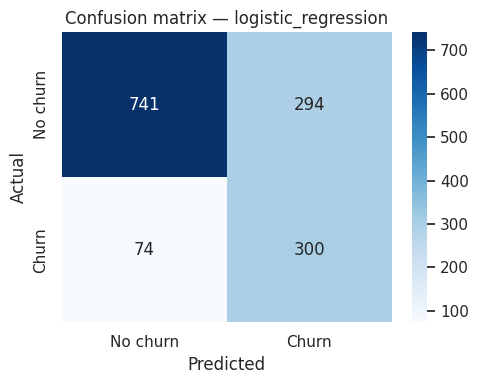

In [14]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No churn", "Churn"], yticklabels=["No churn", "Churn"], ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion matrix — {best_name}")
plt.tight_layout()
plt.show()


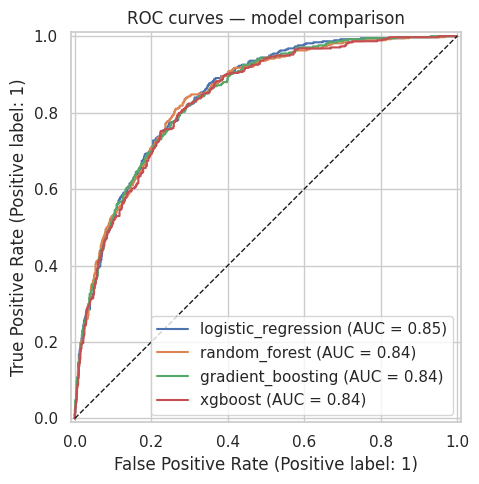

In [15]:
fig, ax = plt.subplots(figsize=(5, 5))
for name, pipe in pipelines.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=ax, name=name)
ax.plot([0, 1], [0, 1], "k--", linewidth=1)
ax.set_title("ROC curves — model comparison")
plt.tight_layout()
plt.show()


## 7. Feature importance / drivers of churn

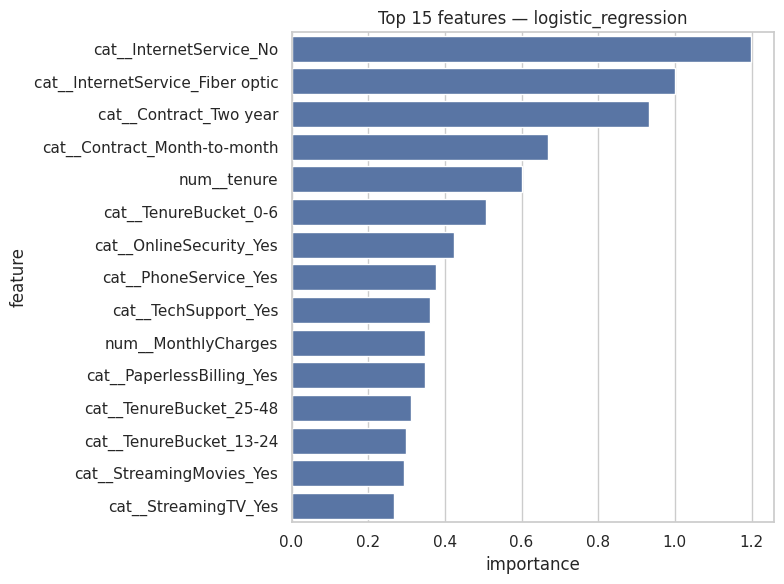

In [16]:
# Works for tree-based models; for logistic regression we use coefficients instead.
import numpy as np

model_step = best_pipeline.named_steps["model"]
preproc_step = best_pipeline.named_steps["preprocessor"]
feature_names = preproc_step.get_feature_names_out()

if hasattr(model_step, "feature_importances_"):
    importances = model_step.feature_importances_
elif hasattr(model_step, "coef_"):
    importances = np.abs(model_step.coef_[0])
else:
    importances = None

if importances is not None:
    imp_df = pd.DataFrame({"feature": feature_names, "importance": importances})
    imp_df = imp_df.sort_values("importance", ascending=False).head(15)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.barplot(data=imp_df, x="importance", y="feature", ax=ax, color="#4C72B0")
    ax.set_title(f"Top 15 features — {best_name}")
    plt.tight_layout()
    plt.show()


## 8. Save the final model

In [17]:
import joblib, os, json

os.makedirs("../models", exist_ok=True)
joblib.dump(best_pipeline, "../models/best_model.pkl")

with open("../models/metrics.json", "w") as f:
    json.dump({"results": results, "best_model": best_name}, f, indent=2)

print("Saved best model:", best_name)


Saved best model: logistic_regression


## 9. Conclusions

- Final model: see `models/metrics.json` for the exact model and metrics selected at run time.
- Churn is concentrated among new, month-to-month, fiber-optic customers paying by electronic check
  who haven't adopted security/support add-ons.
- Recommended next steps for the business: target retention offers at customers in their first
  6 months on month-to-month contracts, and bundle tech support / online security at a discount
  for fiber customers to reduce early churn.
- For productionization, see `src/predict.py`, which loads `models/best_model.pkl` and scores
  new customer records from a CSV.
